# 07 — Loss Functions

This notebook develops loss functions from a simple perceptron residual to MSE and cross-entropy, then visualizes how loss changes across parameter space.

## Topics

- residual error and L1 distance
- mean squared error (MSE)
- MSE loss landscapes over weight and bias
- loss curves for different targets
- logits and multi-class classification
- cross-entropy loss
- cross-entropy loss landscapes


In [2]:
#@title 0) Setup

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

## 1 — Basic Perceptron


In [3]:
class Perceptron(nn.Module):
    def __init__(self, weight: float, bias: float):
        super().__init__()
        self.weight = float(weight)
        self.bias = float(bias)

    def forward(self, x: float) -> float:
        return x * self.weight + self.bias

    def set_weight(self, new_weight: float):
        self.weight = float(new_weight)

    def set_bias(self, new_bias: float):
        self.bias = float(new_bias)

In [4]:
perceptron = Perceptron(weight=0.5, bias=0.2)
input = 1.0
print(perceptron(input))

0.7


In [5]:
perceptron.set_weight(0.8)
perceptron.set_bias(0.1)
print(perceptron(input))

0.9


## 2 — Residual Error

In [7]:
perceptron = Perceptron(weight=0.5, bias=0.2)
y_predicted = perceptron(1.0)
y_expected = 0.5

residual = y_expected - y_predicted
print(f"Math residual: {residual:.4f}")

Math residual: -0.2000


In [8]:
l1_loss = nn.L1Loss()( torch.tensor(y_expected), torch.tensor(y_predicted))
print(f"PyTorch Residual: {l1_loss.item():.4f}")

PyTorch Residual: 0.2000


## 3 — Mean Squared Error (MSE)

In [9]:
mse_math = residual ** 2
print(f"Math MSE: {mse_math:.4f}")

mse_torch = nn.MSELoss()(torch.tensor(y_expected), torch.tensor(y_predicted))
print(f"PyTorch MSE: {mse_torch.item():.4f}")

Math MSE: 0.0400
PyTorch MSE: 0.0400


## 4 — MSE Loss Landscape

In [10]:
#@title Visualize helpers
def visualize_loss():
  # Create a pretty 3D surface plot
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  # Plot the surface
  surf = ax.plot_surface(W, B, Loss, cmap=cm.viridis, edgecolor='none', alpha=0.9)

  # Add labels and title
  ax.set_title(f'MSE Loss Landscape (input={input}, y_expected={y_expected})')
  ax.set_xlabel('Weight')
  ax.set_ylabel('Bias')
  ax.set_zlabel('MSE Loss')

  # Add a color bar which maps values to colors
  fig.colorbar(surf, shrink=0.5, aspect=5, label='Loss')

  plt.tight_layout()
  plt.show()



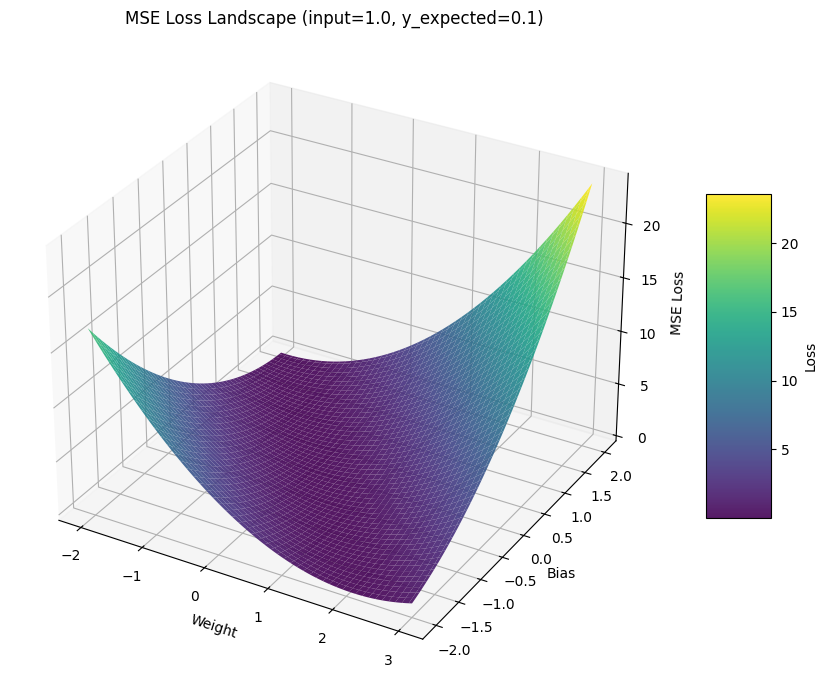

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Create grid of weights and biases
weights = np.linspace(-2.0, 3.0, 100)
biases = np.linspace(-2.0, 2.0, 100)
W, B = np.meshgrid(weights, biases)

input = 1.0
y_expected = 0.1

# We will calculate MSE loss for each combination
Loss = np.zeros_like(W)

# Use the existing perceptron class and its update functions
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        # Update the perceptron with current grid values
        perceptron.set_weight(W[i, j])
        perceptron.set_bias(B[i, j])

        # Predict
        y_predicted = perceptron(input)

        # Calculate MSE loss
        Loss[i, j] = (y_predicted - y_expected)**2

visualize_loss()

## 5 — Loss Curves for Different Targets


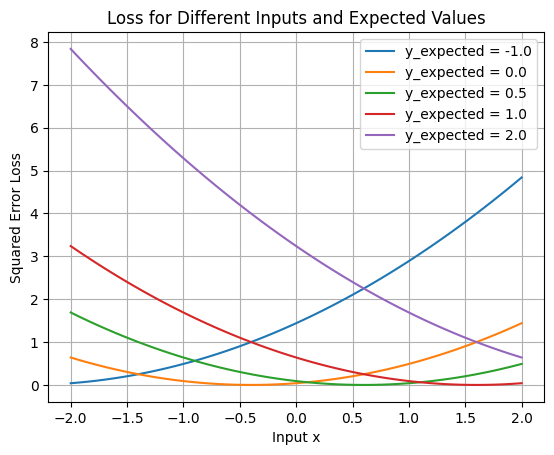

In [16]:
# Visualize the loss for different input and  y_expected values.
import numpy as np
import matplotlib.pyplot as plt

perceptron = Perceptron(weight=0.5, bias=0.2)

# Different input values
inputs = np.linspace(-2, 2, 100)

# Different expected outputs
expected_values = [-1.0, 0.0, 0.5, 1.0, 2.0]

for y_expected in expected_values:
    losses = []

    for x in inputs:
        y_predicted = perceptron(float(x))

        residual = y_expected - y_predicted
        loss = residual ** 2

        losses.append(loss)

    plt.plot(
        inputs,
        losses,
        label=f"y_expected = {y_expected}"
    )

plt.xlabel("Input x")
plt.ylabel("Squared Error Loss")
plt.title("Loss for Different Inputs and Expected Values")
plt.legend()
plt.grid(True)
plt.show()

 ## 6 — Cross-Entropy: 1 → 10 Digit Classification

In [13]:
#@title visualization helpers
def visualize_logits(logits, target_class=None):
    logits_np = logits.detach().numpy().flatten()
    digits = np.arange(10)
    predicted_idx = np.argmax(logits_np)

    plt.figure(figsize=(10, 4))
    colors = ['skyblue' if i != predicted_idx else 'orange' for i in range(10)]

    bars = plt.bar(digits, logits_np, color=colors)

    plt.xticks(digits)
    plt.xlabel('Digit Class')
    plt.ylabel('Logit Value')
    plt.title(f'Logit Visualization (Predicted Digit: {predicted_idx})')

    if target_class is not None:
        target_val = target_class.item()
        plt.axvline(x=target_val, color='red', linestyle='--', alpha=0.6, label=f'Target: {target_val}')
        plt.legend()

    plt.show()

def visualize_loss_surface(W, B, Loss):
  # Create a pretty 3D surface plot
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  # Plot the surface
  surf = ax.plot_surface(W, B, Loss, cmap=cm.viridis, edgecolor='none', alpha=0.9)

  # Add labels and title
  ax.set_title(f'10-Class Cross Entropy Loss Landscape (input={input}, target_class={target_class.item()})')
  ax.set_xlabel('Weight')
  ax.set_ylabel('Bias')
  ax.set_zlabel('CE Loss')

  # Add a color bar which maps values to colors
  fig.colorbar(surf, shrink=0.5, aspect=5, label='Loss')

  plt.tight_layout()
  plt.show()

In [14]:
class DigitMLP(nn.Module):
    def __init__(self, weight: float, bias: float):
        super().__init__()
        self.weight = float(weight)
        self.bias = float(bias)

    def forward(self, x: float):
        neuron_value = x * self.weight + self.bias
        # 10 outputs (logits).
        # highest logit is the predicted first digit
        logits = [1-abs(neuron_value - float(i)) for i in range(10)]
        return torch.tensor([logits])

    def set_weight(self, new_weight: float):
        self.weight = float(new_weight)

    def set_bias(self, new_bias: float):
        self.bias = float(new_bias)

tensor([[-0.3000,  0.7000,  0.3000, -0.7000, -1.7000, -2.7000, -3.7000, -4.7000,
         -5.7000, -6.7000]])


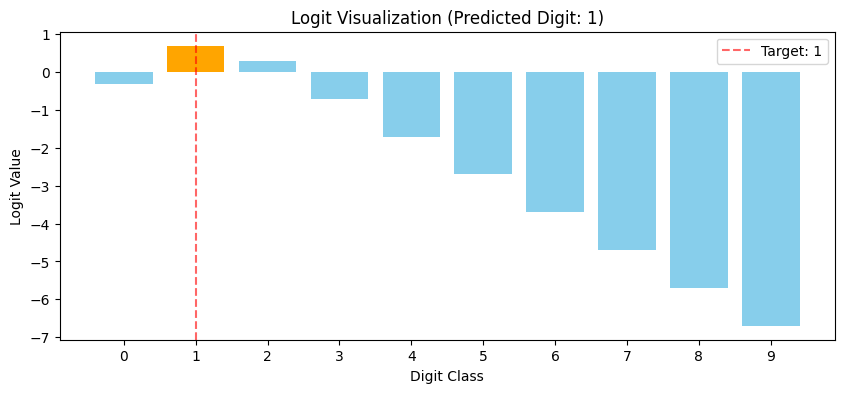

In [15]:
mlp = DigitMLP(weight=1.0, bias=0.0)

input = 1.3
target_class = torch.tensor([1]) # Target is the number 1 at position 1

logits = mlp(input)
print(logits)

visualize_logits(logits, target_class)

In [17]:
# calculate the top logit position
top_logit_position = torch.argmax(logits)
print(top_logit_position)

# calculate cross entropy loss
loss = F.cross_entropy(logits, target_class)
print(loss)

tensor(1)
tensor(0.8870)


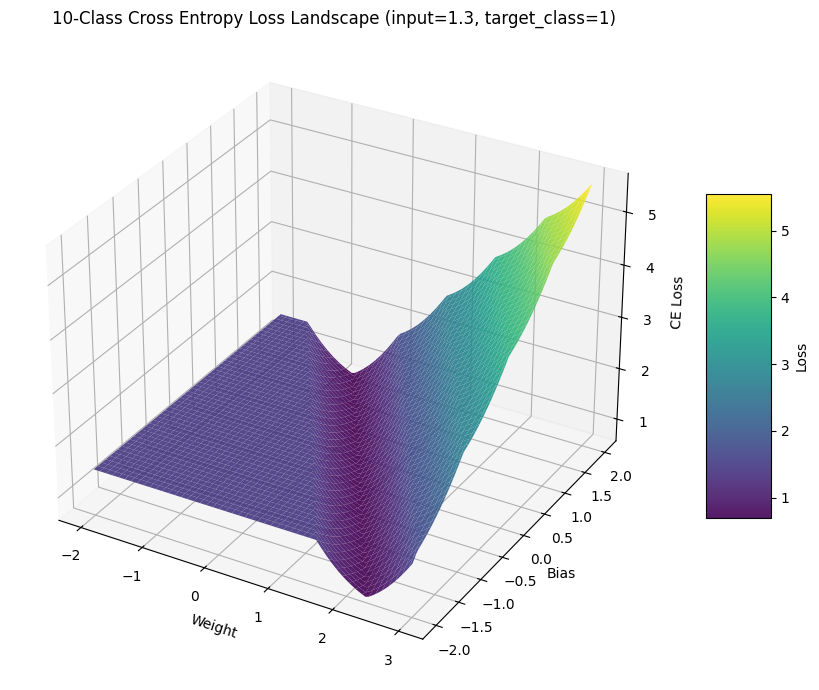

In [18]:
# Walk the W+B space and visualize
weights = np.linspace(-2.0, 3.0, 100)
biases = np.linspace(-2.0, 2.0, 100)
W, B = np.meshgrid(weights, biases)

observed_loss_values = np.zeros_like(W)

# Use the MLP and its update functions
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        # Update MLP with current grid values
        mlp.set_weight(W[i, j])
        mlp.set_bias(B[i, j])

        # Predict
        out_logits = mlp(input)

        # Calculate Cross-Entropy loss
        observed_loss_values[i, j] = F.cross_entropy(out_logits, target_class).item()

visualize_loss_surface(W, B, observed_loss_values)

## 7 — Cross-Entropy with a Different Input/Target

In [ ]:
# Different classification example: input=9, target_class=9
mlp = DigitMLP(weight=1.0, bias=0.0)

input = 9.0
target_class = torch.tensor([9])

logits = mlp(input)
predicted_class = torch.argmax(logits, dim=1)

print("Predicted class:", predicted_class.item())
print("Target class:", target_class.item())
print("Cross-entropy loss:", F.cross_entropy(logits, target_class).item())

visualize_logits(logits, target_class)


---

## Observations

- Residual error preserves direction, while L1 loss measures absolute distance.
- Squaring the residual produces a non-negative objective and penalizes larger errors more strongly.
- A loss landscape treats model parameters as coordinates and loss as the surface height.
- Classification models output logits; `argmax` gives the predicted class, while cross-entropy measures how strongly the model supports the correct class.
- The loss function defines what training should minimize; it does not itself specify how parameters are updated.
